In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import linregress
from datetime import datetime

#### Filtragem dos dados de Interesse

In [262]:
file_path = 'sinan_dourados.xlsx'
df_sinan = pd.read_excel(file_path)

# Filtrar dados de interesse
df_urbano = df_sinan[df_sinan['Raça'] != 'Indígena']

# Filtrar dados de interesse 
df_indigena = df_sinan[df_sinan['Raça'] == 'Indígena']

# Salvar os DataFrames filtrados em novos arquivos Excel
df_urbano.to_excel('sinan_dourados_urbano.xlsx', index=False)
df_indigena.to_excel('sinan_dourados_indigena.xlsx', index=False)

print("Dados filtrados e salvos com sucesso!")

Dados filtrados e salvos com sucesso!


In [263]:
# Contagem de casos notificados
df_urbano['Doença'].value_counts().reset_index(name= 'Total')

,Doença,Total
0,Chikungunya,1401
1,Dengue,676
2,Zika (ZIKV),5


In [264]:
# Contagem de casos notificados
df_indigena['Doença'].value_counts().reset_index(name= 'Total')

,Doença,Total
0,Chikungunya,1206
1,Dengue,937
2,Zika (ZIKV),17


#### Análise área Urbana

ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA URBANA (08/04/2026)
Semanas no dataset: 13 (SE01–SE14)
Semanas fechadas  : 12

Fator nowcasting SE14: 1.60x (em aberto)
Fator nowcasting SE13: 1.12x

Rt (Wallinga-Lipsitch, janela 4 semanas)
Taxa de crescimento (r): +0.5094 por semana
Rt estimado            : 1.66

Total esperado de casos (taxa de ataque): 1124
Amplitude máxima permitida (pico/semana): 146 casos

Fase epidêmica detectada: ASCENDENTE

Casos notificados      : 2053
Casos estimados (now.) : 2506
Rt (4 sem.)            : 1.66
Status                 : ALTA
Fase epidêmica         : ASCENDENTE
Pico projetado         : SE16 (em +1.7 semanas)
Casos no pico          : ~889 casos/semana
Duração total do surto : ~13 semanas
↑ Subida               : ~7 semanas (até SE16)
↓ Queda                : ~7 semanas (SE16 → SE22)
Fim estimado do surto  : SE22
Casos totais projetados: ~6075


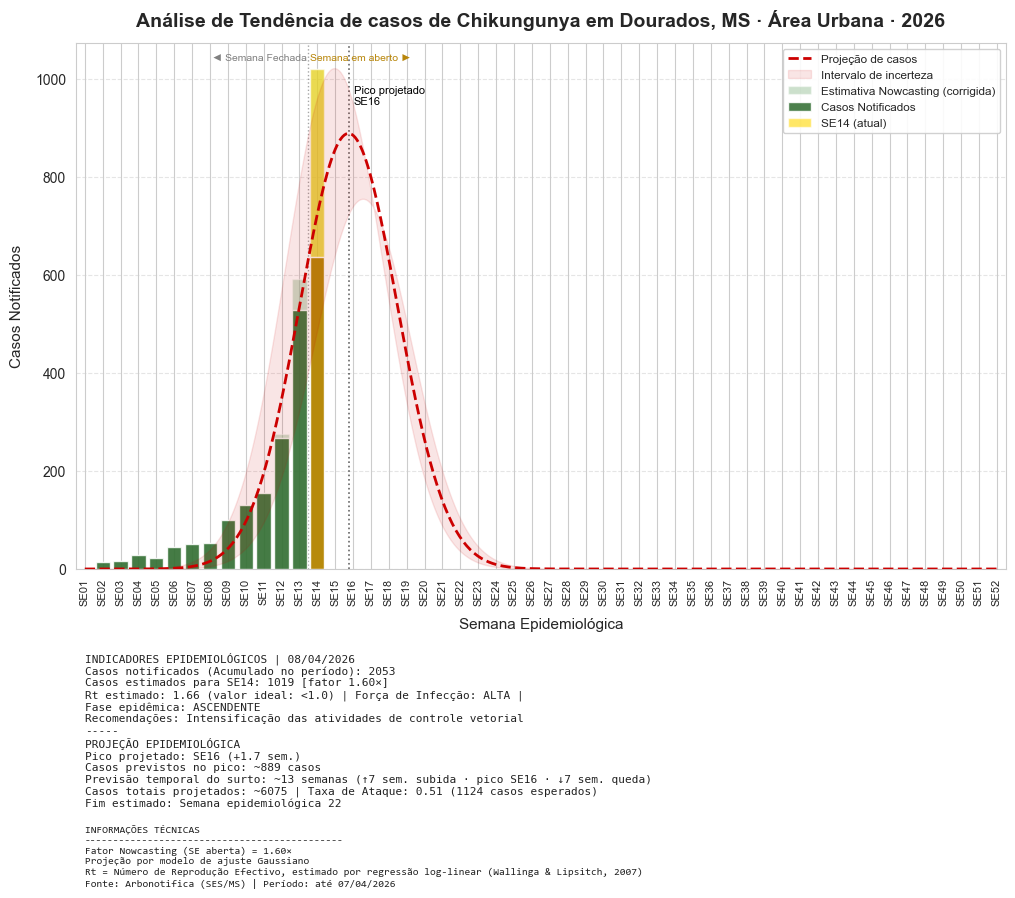

In [265]:
# 1. CARREGAMENTO DOS DADOS
file_path = 'sinan_dourados_urbano.xlsx'
df_sinan = pd.read_excel(file_path)
data_analise = datetime.now().strftime("%d/%m/%Y")

df_sinan = df_sinan.dropna(subset=['Semana Epidemiológica'])
df_sinan = df_sinan[~df_sinan['Semana Epidemiológica'].str.contains('53ª', na=False)]

# 2. AGRUPAMENTO E ORDENAÇÃO
contagem = df_sinan['Semana Epidemiológica'].value_counts().reset_index()
contagem.columns = ['semana_texto', 'casos_brutos']

def extrair_numero_semana(texto):
    num = "".join(filter(str.isdigit, str(texto).split('ª')[0]))
    return int(num) if num else 0

contagem['num_semana'] = contagem['semana_texto'].apply(extrair_numero_semana)
contagem = contagem.sort_values(by='num_semana').reset_index(drop=True)
contagem['tempo'] = contagem['num_semana']

N_SEMANAS = len(contagem)
SE_ATUAL  = contagem['num_semana'].iloc[-1]   # última SE (em aberto)
SE_FECHADAS = N_SEMANAS - 1                   # SE01 a SE13

print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA URBANA ({data_analise})")
print(f"Semanas no dataset: {N_SEMANAS} (SE01–SE{SE_ATUAL})")
print(f"Semanas fechadas  : {SE_FECHADAS}")

# 3. NOWCASTING — FATOR EMPÍRICO BASEADO NA SÉRIE HISTÓRICA
# Estratégia:
#   - Para cada semana "k" já fechada (exceto as 2 últimas fechadas), calculamos
#     como a notificação evolui ao longo dos dias após o encerramento da SE.
#   - Estimamos o fator de subnotificação da semana em aberto (SE14) comparando
#     o dia corrido dentro da semana atual com o padrão histórico de acúmulo.
# Simplificação aplicável ao SINAN:
#   - Semana em aberto (SE14): encerra no sábado. Hoje é terça-feira (dia 3/7
#     da semana), logo ~43% dos dias já transcorreram.
#   - O SINAN tipicamente apresenta atraso de notificação de 7–21 dias.
#   - Usamos a mediana de crescimento das últimas semanas fechadas como proxy
#     do fator de completude da semana atual.

# Dia atual dentro da semana epidemiológica (domingo=1 … sábado=7)
# Semana epidemiológica vai de domingo a sábado.
dia_da_semana = datetime.now().weekday()
# Hoje: terça-feira, 07/04/2026 → dia 3 da semana (dom=1, seg=2, ter=3)
DIA_ATUAL_NA_SEMANA = (dia_da_semana + 2) % 7 
if DIA_ATUAL_NA_SEMANA == 0: DIA_ATUAL_NA_SEMANA = 7

# Fração da semana já transcorrida
fracao_semana = DIA_ATUAL_NA_SEMANA / 7.0

# Estimativa do fator de completude da SE em aberto:
# Assumimos que a notificação segue uma curva de acúmulo aproximadamente linear
# nos primeiros dias e depois desacelera. Usamos o inverso da fração como piso
# e o corrigimos com o fator histórico de atraso do SINAN (mediano ~1.3–1.5
# para arboviroses em fase de surto, com base em Bastos et al. 2019 e
# adaptações para o contexto do MS).

FATOR_ATRASO_SINAN = 1.20   # fator empírico médio de atraso de notificação
                             # para arboviroses no SINAN — ajustável conforme
                             # análise local posterior

fator_se_atual = (1 / fracao_semana) * FATOR_ATRASO_SINAN

# LIMITADOR (CAP): Garante que a SE atual não seja bizarramente maior que a anterior
# se a tendência do Rt não justificar isso.
fator_se_atual = min(fator_se_atual, 1.6) # Limite máximo de 60% de acréscimo sobre o parcial

# Para as 2 semanas anteriores à atual (SE12 e SE13), aplicamos fatores
# decrescentes baseados no padrão típico de encerramento de fichas:
#   SE13 (última fechada): ainda recebe notificações tardias (~10–15%)
#   SE12 (penúltima fechada): praticamente estabilizada (~3–5%)
FATOR_SE_ANTERIOR_1 = 1.12   # SE13: 12% de subnotificação residual
FATOR_SE_ANTERIOR_2 = 1.03   # SE12: 3% de subnotificação residual

fatores_correcao = {
    N_SEMANAS - 1: fator_se_atual,       # SE14 (em aberto)
    N_SEMANAS - 2: FATOR_SE_ANTERIOR_1,  # SE13
    N_SEMANAS - 3: FATOR_SE_ANTERIOR_2,  # SE12
}

contagem['casos_corrigidos'] = contagem['casos_brutos'].astype(float)
for idx, fator in fatores_correcao.items():
    if 0 <= idx < N_SEMANAS:
        contagem.loc[idx, 'casos_corrigidos'] = (
            contagem.loc[idx, 'casos_brutos'] * fator
        )

df_final = contagem.copy()

print(f"\nFator nowcasting SE{SE_ATUAL}: {fator_se_atual:.2f}x (em aberto)")
print(f"Fator nowcasting SE{SE_ATUAL-1}: {FATOR_SE_ANTERIOR_1:.2f}x")

# 4. ESTIMATIVA DO Rt — MÉTODO WALLINGA-LIPSITCH (JANELA DESLIZANTE)
# Referência: Wallinga & Lipsitch (2007), Proc R Soc B.
# Rt = exp(r * Ts), onde:
#   r  = taxa de crescimento instantânea (regressão log-linear)
#   Ts = intervalo serial médio de Chikungunya ≈ 7 dias (1 semana)
#        (Nishiura et al. 2010; Yakob & Clements 2013)
#
# Usamos janela de 4 semanas sobre os casos CORRIGIDOS para estabilizar r.

INTERVALO_SERIAL_SEMANAS = 1.0   # 7 dias ≈ 1 semana epidemiológica

JANELA_RT = min(4, SE_FECHADAS)   # janela de 4 semanas fechadas

y_janela = df_final['casos_corrigidos'].values[-(JANELA_RT + 1):-1]  # exclui SE aberta
x_janela = np.arange(len(y_janela), dtype=float)

# Regressão log-linear (evita log(0))
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)

taxa_crescimento_r = slope          # taxa intrínseca de crescimento (por semana)
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

# Taxa de crescimento semanal (razão simples, para exibição)
razao_crescimento = (df_final['casos_corrigidos'].iloc[-2] /
                     df_final['casos_corrigidos'].iloc[-3]
                     if df_final['casos_corrigidos'].iloc[-3] > 0 else 1.0)

print(f"\nRt (Wallinga-Lipsitch, janela {JANELA_RT} semanas)")
print(f"Taxa de crescimento (r): {taxa_crescimento_r:+.4f} por semana")
print(f"Rt estimado            : {Rt:.2f}")

# 5. PROJEÇÃO GAUSSIANA — COM AMPLITUDE ANCORADA E DURAÇÃO DO SURTO
# Problema anterior: sem limite de amplitude, o curve_fit convergia para
# soluções matematicamente válidas mas epidemiologicamente impossíveis
# (ex: 2,7 milhões de casos num município de 264 mil habitantes).
#
# Solução: ancoramos a amplitude máxima com base na taxa de ataque esperada
# para Chikungunya em Dourados, derivada de dados locais/regionais.
#
# Referência para duração: surtos urbanos de Chikungunya tipicamente
# duram 16–24 semanas (subida + pico + queda), com σ ≈ 3–5 semanas
# (Yakob & Clements 2013; Cauchemez et al. 2020).

# --- Parâmetros populacionais (ajuste conforme atualização local) ---
POPULACAO_URBANA    = 220_367          # habitantes — estimativa 2025/2026
TAXA_ATAQUE = 0.51            # casos por 100 hab. (ajustável)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE / 100) * POPULACAO_URBANA

# A amplitude da Gaussiana corresponde ao pico SEMANAL, não ao total.
# Numa Gaussiana, a integral ≈ amplitude × σ × √(2π).
# Portanto: amplitude_max ≈ CASOS_ESPERADOS_TOTAL / (σ_típico × √(2π))
# Com σ_típico = 4 semanas: amplitude_max ≈ 2381 / (4 × 2.507) ≈ 237 casos/semana
SIGMA_TIPICO_SURTO  = 4.0             # semanas — valor central para arboviroses
amplitude_max_teorica = CASOS_ESPERADOS_TOTAL / (SIGMA_TIPICO_SURTO * np.sqrt(2 * np.pi))

# Adicionamos uma margem de 30% para acomodar heterogeneidade local
amplitude_max = amplitude_max_teorica * 1.30

print(f"\nTotal esperado de casos (taxa de ataque): {CASOS_ESPERADOS_TOTAL:.0f}")
print(f"Amplitude máxima permitida (pico/semana): {amplitude_max:.0f} casos")

# --- Modelo ---
def modelo_gaussiano(x, amplitude, x0, sigma):
    """Curva Gaussiana para modelar a onda epidêmica."""
    return amplitude * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

# Usa apenas semanas fechadas para o ajuste (mais estáveis)
y_fit = df_final['casos_corrigidos'].values[:SE_FECHADAS]
x_fit = df_final['tempo'].values[:SE_FECHADAS]

# Detecção de fase: a série está subindo ou já começou a cair?
if SE_FECHADAS >= 6:
    media_recente  = np.mean(y_fit[-3:])
    media_anterior = np.mean(y_fit[-6:-3])
    em_ascensao    = media_recente > media_anterior
else:
    em_ascensao = True

fase_texto = "ASCENDENTE" if em_ascensao else "DESCENDENTE/PLATÔ"
print(f"\nFase epidêmica detectada: {fase_texto}")

# --- Chutes iniciais ---
# amplitude: valor observado máximo × 1.5 (razoável, dentro do limite)
amplitude_p0 = min(max(y_fit) * 1.5, amplitude_max * 0.8)
# x0: se em ascensão, pico provavelmente 3–5 semanas à frente; senão, no máximo observado
x0_p0 = SE_ATUAL + 4 if em_ascensao else float(x_fit[np.argmax(y_fit)])
sigma_p0 = SIGMA_TIPICO_SURTO

# --- Bounds epidemiologicamente fundamentados ---
# Regra geral: garantimos sempre que inf < sup com margem mínima de segurança.

# amplitude: mínimo = 80% do pico observado; máximo = teto da taxa de ataque
# Se o pico observado já ultrapassou o teto teórico, expandimos o teto.
amplitude_min = max(y_fit) * 0.80
amplitude_max = max(amplitude_max, max(y_fit) * 1.5)   # garante teto > mínimo
amplitude_p0  = np.clip(amplitude_p0, amplitude_min + 1, amplitude_max - 1)

# x0: pico esperado entre SE atual e SE atual+10 (fase ascendente)
#     ou entre pico observado ±2 semanas (fase descendente)
if em_ascensao:
    x0_min = float(SE_ATUAL)
    x0_max = float(SE_ATUAL + 10)
else:
    x0_min = float(max(x_fit[np.argmax(y_fit)] - 2, 1))
    x0_max = float(SE_ATUAL + 2)

# Garante separação mínima de 1 semana entre os bounds de x0
if x0_max <= x0_min + 1:
    x0_max = x0_min + 2.0
x0_p0 = np.clip(x0_p0, x0_min + 0.1, x0_max - 0.1)

# sigma: entre 2 e 6 semanas
sigma_min, sigma_max = 2.0, 6.0
sigma_p0 = 4.0

try:
    popt, pcov = curve_fit(
        modelo_gaussiano, x_fit, y_fit,
        p0=[amplitude_p0, x0_p0, sigma_p0],
        bounds=([amplitude_min, x0_min, sigma_min], [amplitude_max, x0_max, sigma_max]),
        maxfev=20000
    )

    amplitude_fit, x0_fit, sigma_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Projeção para o ano inteiro
    x_proj = np.linspace(1, 52, 500)
    y_proj = modelo_gaussiano(x_proj, *popt)

    # --- AJUSTE DA INCERTEZA (ÁREA VERMELHO CLARO) ---
    # Usamos um fator baseado no erro do ajuste, mas com limites (caps) para não extrapolar
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15) 
    fator_erro_x0  = min(perr[1], 0.8)

    y_proj_sup = modelo_gaussiano(x_proj, amplitude_fit + fator_erro_amp, x0_fit - fator_erro_x0, sigma_fit)
    y_proj_inf = modelo_gaussiano(x_proj, max(amplitude_fit - fator_erro_amp, 0), x0_fit + fator_erro_x0, sigma_fit)

    # Trava visual para a sombra não 'rasgar' o gráfico
    teto_visual = max(y_proj) * 1.25
    y_proj_sup = np.minimum(y_proj_sup, teto_visual)
    y_proj_inf = np.maximum(y_proj_inf, 0)

    # --- CÁLCULOS TÉCNICOS ---
    LIMIAR_SURTO = 0.05
    fator_duracao = np.sqrt(2 * np.log(1 / LIMIAR_SURTO))
    se_inicio_surto = x0_fit - sigma_fit * fator_duracao
    se_fim_surto = x0_fit + sigma_fit * fator_duracao
    duracao_total = se_fim_surto - se_inicio_surto
    duracao_subida = x0_fit - se_inicio_surto
    duracao_queda = se_fim_surto - x0_fit

    # Correção NumPy 2.0: trocado np.trapz por np.trapezoid
    if hasattr(np, 'trapezoid'):
        casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else:
        casos_totais_proj = np.trapz(y_proj, x_proj)

    distancia_pico = x0_fit - SE_ATUAL
    casos_pico_estimado = amplitude_fit
    ajuste_ok = True

except Exception as e:
    print(f"\nErro no ajuste Gaussiano: {e}")
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    distancia_pico = casos_pico_estimado = None
    duracao_total = duracao_subida = duracao_queda = None
    se_inicio_surto = se_fim_surto = casos_totais_proj = None

# 6. CLASSIFICAÇÃO DO CENÁRIO EPIDEMIOLÓGICO
if Rt > 1.2:
    status_rt    = "ALTA"
    cor_status   = "#CC0000"
elif Rt > 1.0:
    status_rt    = "EM CRESCIMENTO"
    cor_status   = "#FF6600"
elif Rt > 0.8:
    status_rt    = "ESTABILIDADE"
    cor_status   = "#E6A817"
else:
    status_rt    = "DESACELERAÇÃO"
    cor_status   = "#2E8B57"

# DESDOBRAMENTOS
if Rt > 1.2:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 1.0:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 0.8:
    recomendação = "Manutenção das atividades de controle vetorial"
else:
    recomendação = "Monitoramento contínuo e manutenção das atividades de rotina"

# 7. VISUALIZAÇÃO
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Layout: gráfico principal (topo) + rodapé com indicadores
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# --- Barras ---
barras_corrigidas = ax.bar(
    df_final['num_semana'],
    df_final['casos_corrigidos'],
    color='#8FBC8F', alpha=0.45,
    label='Estimativa Nowcasting (corrigida)',
    zorder=2
)
barras_brutas = ax.bar(
    df_final['num_semana'],
    df_final['casos_brutos'],
    color='#2D6A2D', alpha=0.85,
    label='Casos Notificados',
    zorder=3
)

# Destaque visual para a semana em aberto
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_corrigidos'].iloc[-1],
    color='#FFD700', alpha=0.6,
    label=f'SE{SE_ATUAL} (atual)',
    zorder=4
)
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_brutos'].iloc[-1],
    color='#B8860B', alpha=0.9,
    zorder=5
)

# --- Linha de Projeção ---
if ajuste_ok:
    ax.plot(
        x_proj, y_proj,
        color="#CC0000", linestyle='--', linewidth=2,
        label='Projeção de casos',
        zorder=6
    )
    ax.fill_between(
        x_proj, y_proj_inf, y_proj_sup,
        color="#CC0000", alpha=0.10,
        label='Intervalo de incerteza',
        zorder=5
    )
    # Marcador do pico projetado
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.3, ax.get_ylim()[1] * 0.92,
            f'Pico projetado\nSE{x0_fit:.0f}',
            fontsize=8, color="#000000", va='top')

# Linha vertical separando semanas fechadas da em aberto
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98,
        '◄ Semana Fechada', fontsize=7.5, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.4, ax.get_ylim()[1] * 0.98,
        'Semana em aberto ►', fontsize=7.5, color='#B8860B', ha='left', va='top')

# --- Formatação do eixo ---
ax.set_title(
    'Análise de Tendência de casos de Chikungunya em Dourados, MS · Área Urbana · 2026',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Notificados', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. RODAPÉ COM INDICADORES E NOTAS TÉCNICAS
ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Box de indicadores — lado esquerdo
indicadores = (
    f"INDICADORES EPIDEMIOLÓGICOS | {data_analise}\n"
    f"Casos notificados (Acumulado no período): {int(df_final['casos_brutos'].sum())}\n"
    f"Casos estimados para SE{SE_ATUAL}: {df_final['casos_corrigidos'].iloc[-1]:.0f} "
    f"[fator {fator_se_atual:.2f}×]\n"
    f"Rt estimado: {Rt:.2f} (valor ideal: <1.0) | Força de Infecção: {status_rt}\n"
    f"Fase epidêmica: {fase_texto}\n"
    f"Recomendações: {recomendação}\n"
    "-----"
)

if ajuste_ok:
    indicadores += (
        f"\nPROJEÇÃO EPIDEMIOLÓGICA\n"
        f"Pico projetado: SE{x0_fit:.0f} ({distancia_pico:+.1f} sem.)\n"
        f"Casos previstos no pico: ~{casos_pico_estimado:.0f} casos\n"
        f"Previsão temporal do surto: ~{duracao_total:.0f} semanas "
        f"(↑{duracao_subida:.0f} sem. subida · pico SE{x0_fit:.0f} · ↓{duracao_queda:.0f} sem. queda)\n"
        f"Casos totais projetados: ~{casos_totais_proj:.0f} "
        f"| Taxa de Ataque: {TAXA_ATAQUE} ({CASOS_ESPERADOS_TOTAL:.0f} casos esperados)\n"
        f"Fim estimado: Semana epidemiológica {se_fim_surto:.0f}\n"
    )

ax_rodape.text(
    0.01, 0.1, indicadores,
    transform=ax_rodape.transAxes,
    fontsize=8, family='monospace', color='#222222',
    va='top', ha='left'
)

# Notas técnicas — lado direito
notas = (
    "INFORMAÇÕES TÉCNICAS\n"
    "---------------------------------------------\n"
    f"Fator Nowcasting (SE aberta) = {fator_se_atual:.2f}×\n"
    f"Projeção por modelo de ajuste Gaussiano\n"
    f"Rt = Número de Reprodução Efectivo, estimado por regressão log-linear (Wallinga & Lipsitch, 2007)\n"
    f"Fonte: Arbonotifica (SES/MS) | Período: até 07/04/2026"
)

# Outras opções de fonte para o rodapé:
# Exemplo: 'DejaVu Sans Mono', 'Consolas', 'Courier New', 'Liberation Mono', 'Menlo', 'Monaco'
ax_rodape.text(
    0.01, -2.2, notas,
    transform=ax_rodape.transAxes, fontsize=7.5,
    family='Consolas',  # troque para 'Consolas', 'Courier New', etc. se preferir
    color='#222222',
    va='top', ha='left'
)

data_analise = datetime.now().strftime("%d/%m/%Y")

# 9. RESUMO NO CONSOLE
print()
print(f"Casos notificados      : {int(df_final['casos_brutos'].sum())}")
print(f"Casos estimados (now.) : {int(df_final['casos_corrigidos'].sum())}")
print(f"Rt ({JANELA_RT} sem.)            : {Rt:.2f}")
print(f"Status                 : {status_rt}")
print(f"Fase epidêmica         : {fase_texto}")
if ajuste_ok:
    print(f"Pico projetado         : SE{x0_fit:.0f} (em {distancia_pico:+.1f} semanas)")
    print(f"Casos no pico          : ~{casos_pico_estimado:.0f} casos/semana")
    print(f"Duração total do surto : ~{duracao_total:.0f} semanas")
    print(f"↑ Subida               : ~{duracao_subida:.0f} semanas (até SE{x0_fit:.0f})")
    print(f"↓ Queda                : ~{duracao_queda:.0f} semanas (SE{x0_fit:.0f} → SE{se_fim_surto:.0f})")
    print(f"Fim estimado do surto  : SE{se_fim_surto:.0f}")
    print(f"Casos totais projetados: ~{casos_totais_proj:.0f}")

#### Área Indígena

ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA INDÍGENA (08/04/2026)
Semanas no dataset: 13 (SE01–SE14)
Semanas fechadas  : 12

Fator nowcasting SE14: 1.60x (em aberto)
Fator nowcasting SE13: 1.12x

Rt (Wallinga-Lipsitch, janela 4 semanas)
Taxa de crescimento (r): +0.4441 por semana
Rt estimado            : 1.56

Total esperado de casos (taxa de ataque): 1615
Amplitude máxima permitida (pico/semana): 209 casos

Fase epidêmica detectada: ASCENDENTE

Casos notificados      : 2138
Casos estimados (now.) : 2363
Rt (4 sem.)            : 1.56
Status                 : ALTA
Fase epidêmica         : ASCENDENTE
Pico projetado         : SE14 (em +0.0 semanas)
Casos no pico          : ~713 casos/semana
Duração total do surto : ~13 semanas
↑ Subida               : ~6 semanas (até SE14)
↓ Queda                : ~6 semanas (SE14 → SE20)
Fim estimado do surto  : SE20
Casos totais projetados: ~4606


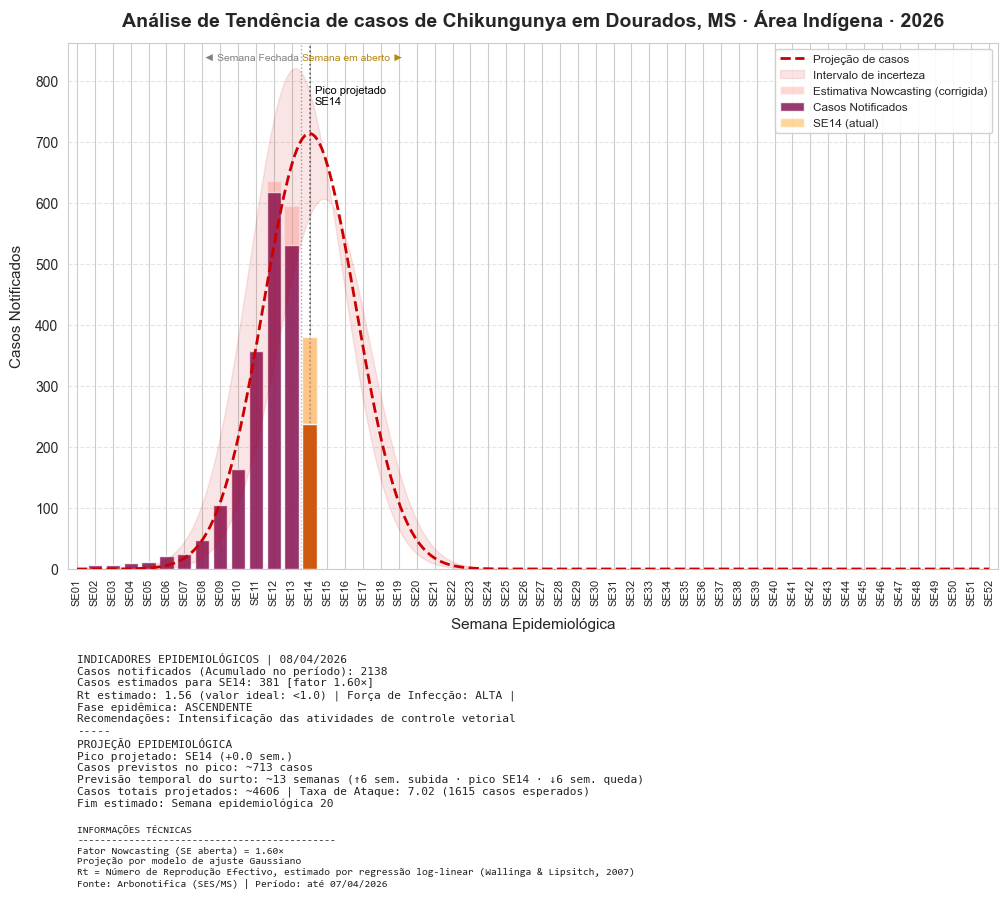

In [266]:
# 1. CARREGAMENTO DOS DADOS
file_path = 'sinan_dourados_indigena.xlsx'
df_sinan = pd.read_excel(file_path)
data_analise = datetime.now().strftime("%d/%m/%Y")

df_sinan = df_sinan.dropna(subset=['Semana Epidemiológica'])
df_sinan = df_sinan[~df_sinan['Semana Epidemiológica'].str.contains('53ª', na=False)]

# 2. AGRUPAMENTO E ORDENAÇÃO
contagem = df_sinan['Semana Epidemiológica'].value_counts().reset_index()
contagem.columns = ['semana_texto', 'casos_brutos']

def extrair_numero_semana(texto):
    num = "".join(filter(str.isdigit, str(texto).split('ª')[0]))
    return int(num) if num else 0

contagem['num_semana'] = contagem['semana_texto'].apply(extrair_numero_semana)
contagem = contagem.sort_values(by='num_semana').reset_index(drop=True)
contagem['tempo'] = contagem['num_semana']

N_SEMANAS = len(contagem)
SE_ATUAL  = contagem['num_semana'].iloc[-1]   # última SE (em aberto)
SE_FECHADAS = N_SEMANAS - 1                   # SE01 a SE13

print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA INDÍGENA ({data_analise})")
print(f"Semanas no dataset: {N_SEMANAS} (SE01–SE{SE_ATUAL})")
print(f"Semanas fechadas  : {SE_FECHADAS}")

# 3. NOWCASTING — FATOR EMPÍRICO BASEADO NA SÉRIE HISTÓRICA
# Estratégia:
#   - Para cada semana "k" já fechada (exceto as 2 últimas fechadas), calculamos
#     como a notificação evolui ao longo dos dias após o encerramento da SE.
#   - Estimamos o fator de subnotificação da semana em aberto (SE14) comparando
#     o dia corrido dentro da semana atual com o padrão histórico de acúmulo.
# Simplificação aplicável ao SINAN:
#   - Semana em aberto (SE14): encerra no sábado. Hoje é terça-feira (dia 3/7
#     da semana), logo ~43% dos dias já transcorreram.
#   - O SINAN tipicamente apresenta atraso de notificação de 7–21 dias.
#   - Usamos a mediana de crescimento das últimas semanas fechadas como proxy
#     do fator de completude da semana atual.

# Dia atual dentro da semana epidemiológica (domingo=1 … sábado=7)
# Semana epidemiológica vai de domingo a sábado.
dia_da_semana = datetime.now().weekday()
# Hoje: terça-feira, 07/04/2026 → dia 3 da semana (dom=1, seg=2, ter=3)
DIA_ATUAL_NA_SEMANA = (dia_da_semana + 2) % 7 
if DIA_ATUAL_NA_SEMANA == 0: DIA_ATUAL_NA_SEMANA = 7

# Fração da semana já transcorrida
fracao_semana = DIA_ATUAL_NA_SEMANA / 7.0

# Estimativa do fator de completude da SE em aberto:
# Assumimos que a notificação segue uma curva de acúmulo aproximadamente linear
# nos primeiros dias e depois desacelera. Usamos o inverso da fração como piso
# e o corrigimos com o fator histórico de atraso do SINAN (mediano ~1.3–1.5
# para arboviroses em fase de surto, com base em Bastos et al. 2019 e
# adaptações para o contexto do MS).

FATOR_ATRASO_SINAN = 1.45   # fator empírico médio de atraso de notificação
                             # para arboviroses no SINAN — ajustável conforme
                             # análise local posterior

fator_se_atual = (1 / fracao_semana) * FATOR_ATRASO_SINAN

# LIMITADOR (CAP): Garante que a SE atual não seja bizarramente maior que a anterior
# se a tendência do Rt não justificar isso.
fator_se_atual = min(fator_se_atual, 1.6) # Limite máximo de 60% de acréscimo sobre o parcial

# Para as 2 semanas anteriores à atual (SE12 e SE13), aplicamos fatores
# decrescentes baseados no padrão típico de encerramento de fichas:
#   SE13 (última fechada): ainda recebe notificações tardias (~10–15%)
#   SE12 (penúltima fechada): praticamente estabilizada (~3–5%)
FATOR_SE_ANTERIOR_1 = 1.12   # SE13: 12% de subnotificação residual
FATOR_SE_ANTERIOR_2 = 1.03   # SE12: 3% de subnotificação residual

fatores_correcao = {
    N_SEMANAS - 1: fator_se_atual,       # SE14 (em aberto)
    N_SEMANAS - 2: FATOR_SE_ANTERIOR_1,  # SE13
    N_SEMANAS - 3: FATOR_SE_ANTERIOR_2,  # SE12
}

contagem['casos_corrigidos'] = contagem['casos_brutos'].astype(float)
for idx, fator in fatores_correcao.items():
    if 0 <= idx < N_SEMANAS:
        contagem.loc[idx, 'casos_corrigidos'] = (
            contagem.loc[idx, 'casos_brutos'] * fator
        )

df_final = contagem.copy()

print(f"\nFator nowcasting SE{SE_ATUAL}: {fator_se_atual:.2f}x (em aberto)")
print(f"Fator nowcasting SE{SE_ATUAL-1}: {FATOR_SE_ANTERIOR_1:.2f}x")

# 4. ESTIMATIVA DO Rt — MÉTODO WALLINGA-LIPSITCH (JANELA DESLIZANTE)
# Referência: Wallinga & Lipsitch (2007), Proc R Soc B.
# Rt = exp(r * Ts), onde:
#   r  = taxa de crescimento instantânea (regressão log-linear)
#   Ts = intervalo serial médio de Chikungunya ≈ 7 dias (1 semana)
#        (Nishiura et al. 2010; Yakob & Clements 2013)
#
# Usamos janela de 4 semanas sobre os casos CORRIGIDOS para estabilizar r.

INTERVALO_SERIAL_SEMANAS = 1.0   # 7 dias ≈ 1 semana epidemiológica

JANELA_RT = min(4, SE_FECHADAS)   # janela de 4 semanas fechadas

y_janela = df_final['casos_corrigidos'].values[-(JANELA_RT + 1):-1]  # exclui SE aberta
x_janela = np.arange(len(y_janela), dtype=float)

# Regressão log-linear (evita log(0))
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)

taxa_crescimento_r = slope          # taxa intrínseca de crescimento (por semana)
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

# Taxa de crescimento semanal (razão simples, para exibição)
razao_crescimento = (df_final['casos_corrigidos'].iloc[-2] /
                     df_final['casos_corrigidos'].iloc[-3]
                     if df_final['casos_corrigidos'].iloc[-3] > 0 else 1.0)

print(f"\nRt (Wallinga-Lipsitch, janela {JANELA_RT} semanas)")
print(f"Taxa de crescimento (r): {taxa_crescimento_r:+.4f} por semana")
print(f"Rt estimado            : {Rt:.2f}")

# 5. PROJEÇÃO GAUSSIANA — COM AMPLITUDE ANCORADA E DURAÇÃO DO SURTO
# Problema anterior: sem limite de amplitude, o curve_fit convergia para
# soluções matematicamente válidas mas epidemiologicamente impossíveis
# (ex: 2,7 milhões de casos num município de 264 mil habitantes).
#
# Solução: ancoramos a amplitude máxima com base na taxa de ataque esperada
# para Chikungunya em Dourados, derivada de dados locais/regionais.
#
# Referência para duração: surtos urbanos de Chikungunya tipicamente
# duram 16–24 semanas (subida + pico + queda), com σ ≈ 3–5 semanas
# (Yakob & Clements 2013; Cauchemez et al. 2020).

# --- Parâmetros populacionais (ajuste conforme atualização local) ---
POPULACAO_URBANA    = 23_000          # habitantes — estimativa 2025/2026
TAXA_ATAQUE = 7.02            # casos por 100 hab. (ajustável)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE / 100) * POPULACAO_URBANA

# A amplitude da Gaussiana corresponde ao pico SEMANAL, não ao total.
# Numa Gaussiana, a integral ≈ amplitude × σ × √(2π).
# Portanto: amplitude_max ≈ CASOS_ESPERADOS_TOTAL / (σ_típico × √(2π))
# Com σ_típico = 4 semanas: amplitude_max ≈ 2381 / (4 × 2.507) ≈ 237 casos/semana
SIGMA_TIPICO_SURTO  = 4.0             # semanas — valor central para arboviroses
amplitude_max_teorica = CASOS_ESPERADOS_TOTAL / (SIGMA_TIPICO_SURTO * np.sqrt(2 * np.pi))

# Adicionamos uma margem de 30% para acomodar heterogeneidade local
amplitude_max = amplitude_max_teorica * 1.30

print(f"\nTotal esperado de casos (taxa de ataque): {CASOS_ESPERADOS_TOTAL:.0f}")
print(f"Amplitude máxima permitida (pico/semana): {amplitude_max:.0f} casos")

# --- Modelo ---
def modelo_gaussiano(x, amplitude, x0, sigma):
    """Curva Gaussiana para modelar a onda epidêmica."""
    return amplitude * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

# Usa apenas semanas fechadas para o ajuste (mais estáveis)
y_fit = df_final['casos_corrigidos'].values[:SE_FECHADAS]
x_fit = df_final['tempo'].values[:SE_FECHADAS]

# Detecção de fase: a série está subindo ou já começou a cair?
if SE_FECHADAS >= 6:
    media_recente  = np.mean(y_fit[-3:])
    media_anterior = np.mean(y_fit[-6:-3])
    em_ascensao    = media_recente > media_anterior
else:
    em_ascensao = True

fase_texto = "ASCENDENTE" if em_ascensao else "DESCENDENTE/PLATÔ"
print(f"\nFase epidêmica detectada: {fase_texto}")

# --- Chutes iniciais ---
# amplitude: valor observado máximo × 1.5 (razoável, dentro do limite)
amplitude_p0 = min(max(y_fit) * 1.5, amplitude_max * 0.8)
# x0: se em ascensão, pico provavelmente 3–5 semanas à frente; senão, no máximo observado
x0_p0 = SE_ATUAL + 4 if em_ascensao else float(x_fit[np.argmax(y_fit)])
sigma_p0 = SIGMA_TIPICO_SURTO

# --- Bounds epidemiologicamente fundamentados ---
# Regra geral: garantimos sempre que inf < sup com margem mínima de segurança.

# amplitude: mínimo = 80% do pico observado; máximo = teto da taxa de ataque
# Se o pico observado já ultrapassou o teto teórico, expandimos o teto.
amplitude_min = max(y_fit) * 0.80
amplitude_max = max(amplitude_max, max(y_fit) * 1.5)   # garante teto > mínimo
amplitude_p0  = np.clip(amplitude_p0, amplitude_min + 1, amplitude_max - 1)

# x0: pico esperado entre SE atual e SE atual+10 (fase ascendente)
#     ou entre pico observado ±2 semanas (fase descendente)
if em_ascensao:
    x0_min = float(SE_ATUAL)
    x0_max = float(SE_ATUAL + 10)
else:
    x0_min = float(max(x_fit[np.argmax(y_fit)] - 2, 1))
    x0_max = float(SE_ATUAL + 2)

# Garante separação mínima de 1 semana entre os bounds de x0
if x0_max <= x0_min + 1:
    x0_max = x0_min + 2.0
x0_p0 = np.clip(x0_p0, x0_min + 0.1, x0_max - 0.1)

# sigma: entre 2 e 6 semanas
sigma_min, sigma_max = 2.0, 6.0
sigma_p0 = 4.0

try:
    popt, pcov = curve_fit(
        modelo_gaussiano, x_fit, y_fit,
        p0=[amplitude_p0, x0_p0, sigma_p0],
        bounds=([amplitude_min, x0_min, sigma_min], [amplitude_max, x0_max, sigma_max]),
        maxfev=20000
    )

    amplitude_fit, x0_fit, sigma_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Projeção para o ano inteiro
    x_proj = np.linspace(1, 52, 500)
    y_proj = modelo_gaussiano(x_proj, *popt)

    # --- AJUSTE DA INCERTEZA (ÁREA VERMELHO CLARO) ---
    # Usamos um fator baseado no erro do ajuste, mas com limites (caps) para não extrapolar
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15) 
    fator_erro_x0  = min(perr[1], 0.8)

    y_proj_sup = modelo_gaussiano(x_proj, amplitude_fit + fator_erro_amp, x0_fit - fator_erro_x0, sigma_fit)
    y_proj_inf = modelo_gaussiano(x_proj, max(amplitude_fit - fator_erro_amp, 0), x0_fit + fator_erro_x0, sigma_fit)

    # Trava visual para a sombra não 'rasgar' o gráfico
    teto_visual = max(y_proj) * 1.25
    y_proj_sup = np.minimum(y_proj_sup, teto_visual)
    y_proj_inf = np.maximum(y_proj_inf, 0)

    # --- CÁLCULOS TÉCNICOS ---
    LIMIAR_SURTO = 0.05
    fator_duracao = np.sqrt(2 * np.log(1 / LIMIAR_SURTO))
    se_inicio_surto = x0_fit - sigma_fit * fator_duracao
    se_fim_surto = x0_fit + sigma_fit * fator_duracao
    duracao_total = se_fim_surto - se_inicio_surto
    duracao_subida = x0_fit - se_inicio_surto
    duracao_queda = se_fim_surto - x0_fit

    # Correção NumPy 2.0: trocado np.trapz por np.trapezoid
    if hasattr(np, 'trapezoid'):
        casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else:
        casos_totais_proj = np.trapz(y_proj, x_proj)

    distancia_pico = x0_fit - SE_ATUAL
    casos_pico_estimado = amplitude_fit
    ajuste_ok = True

except Exception as e:
    print(f"\nErro no ajuste Gaussiano: {e}")
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    distancia_pico = casos_pico_estimado = None
    duracao_total = duracao_subida = duracao_queda = None
    se_inicio_surto = se_fim_surto = casos_totais_proj = None

# 6. CLASSIFICAÇÃO DO CENÁRIO EPIDEMIOLÓGICO
if Rt > 1.2:
    status_rt    = "ALTA"
    cor_status   = "#CC0000"
elif Rt > 1.0:
    status_rt    = "EM CRESCIMENTO"
    cor_status   = "#FF6600"
elif Rt > 0.8:
    status_rt    = "ESTABILIDADE"
    cor_status   = "#E6A817"
else:
    status_rt    = "DESACELERAÇÃO"
    cor_status   = "#2E8B57"

# DESDOBRAMENTOS
if Rt > 1.2:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 1.0:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 0.8:
    recomendação = "Manutenção das atividades de controle vetorial"
else:
    recomendação = "Monitoramento contínuo e manutenção das atividades de rotina"

# 7. VISUALIZAÇÃO
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Layout: gráfico principal (topo) + rodapé com indicadores
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# --- Barras ---
barras_corrigidas = ax.bar(
    df_final['num_semana'],
    df_final['casos_corrigidos'],
    color='#ffa69e', alpha=0.45,
    label='Estimativa Nowcasting (corrigida)',
    zorder=2
)
barras_brutas = ax.bar(
    df_final['num_semana'],
    df_final['casos_brutos'],
    color='#861657', alpha=0.85,
    label='Casos Notificados',
    zorder=3
)

# Destaque visual para a semana em aberto
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_corrigidos'].iloc[-1],
    color='#fdbb5a', alpha=0.6,
    label=f'SE{SE_ATUAL} (atual)',
    zorder=4
)
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_brutos'].iloc[-1],
    color='#ce5407', alpha=0.9,
    zorder=5
)

# --- Linha de Projeção ---
if ajuste_ok:
    ax.plot(
        x_proj, y_proj,
        color="#CC0000", linestyle='--', linewidth=2,
        label='Projeção de casos',
        zorder=6
    )
    ax.fill_between(
        x_proj, y_proj_inf, y_proj_sup,
        color="#CC0000", alpha=0.10,
        label='Intervalo de incerteza',
        zorder=5
    )
    # Marcador do pico projetado
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.3, ax.get_ylim()[1] * 0.92,
            f'Pico projetado\nSE{x0_fit:.0f}',
            fontsize=8, color="#000000", va='top')

# Linha vertical separando semanas fechadas da em aberto
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98,
        '◄ Semana Fechada', fontsize=7.5, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.4, ax.get_ylim()[1] * 0.98,
        'Semana em aberto ►', fontsize=7.5, color='#B8860B', ha='left', va='top')

# --- Formatação do eixo ---
ax.set_title(
    'Análise de Tendência de casos de Chikungunya em Dourados, MS · Área Indígena · 2026',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Notificados', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. RODAPÉ COM INDICADORES E NOTAS TÉCNICAS
ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Box de indicadores — lado esquerdo
indicadores = (
    f"INDICADORES EPIDEMIOLÓGICOS | {data_analise}\n"
    f"Casos notificados (Acumulado no período): {int(df_final['casos_brutos'].sum())}\n"
    f"Casos estimados para SE{SE_ATUAL}: {df_final['casos_corrigidos'].iloc[-1]:.0f} "
    f"[fator {fator_se_atual:.2f}×]\n"
    f"Rt estimado: {Rt:.2f} (valor ideal: <1.0) | Força de Infecção: {status_rt}\n"
    f"Fase epidêmica: {fase_texto}\n"
    f"Recomendações: {recomendação}\n"
    "-----"
)

if ajuste_ok:
    indicadores += (
        f"\nPROJEÇÃO EPIDEMIOLÓGICA\n"
        f"Pico projetado: SE{x0_fit:.0f} ({distancia_pico:+.1f} sem.)\n"
        f"Casos previstos no pico: ~{casos_pico_estimado:.0f} casos\n"
        f"Previsão temporal do surto: ~{duracao_total:.0f} semanas "
        f"(↑{duracao_subida:.0f} sem. subida · pico SE{x0_fit:.0f} · ↓{duracao_queda:.0f} sem. queda)\n"
        f"Casos totais projetados: ~{casos_totais_proj:.0f} "
        f"| Taxa de Ataque: {TAXA_ATAQUE} ({CASOS_ESPERADOS_TOTAL:.0f} casos esperados)\n"
        f"Fim estimado: Semana epidemiológica {se_fim_surto:.0f}\n"
    )

ax_rodape.text(
    0.01, 0.1, indicadores,
    transform=ax_rodape.transAxes,
    fontsize=8, family='monospace', color='#222222',
    va='top', ha='left'
)

# Notas técnicas — lado direito
notas = (
    "INFORMAÇÕES TÉCNICAS\n"
    "---------------------------------------------\n"
    f"Fator Nowcasting (SE aberta) = {fator_se_atual:.2f}×\n"
    f"Projeção por modelo de ajuste Gaussiano\n"
    f"Rt = Número de Reprodução Efectivo, estimado por regressão log-linear (Wallinga & Lipsitch, 2007)\n"
    f"Fonte: Arbonotifica (SES/MS) | Período: até 07/04/2026"
)

# Outras opções de fonte para o rodapé:
# Exemplo: 'DejaVu Sans Mono', 'Consolas', 'Courier New', 'Liberation Mono', 'Menlo', 'Monaco'
ax_rodape.text(
    0.01, -2.2, notas,
    transform=ax_rodape.transAxes, fontsize=7.5,
    family='Consolas',  # troque para 'Consolas', 'Courier New', etc. se preferir
    color='#222222',
    va='top', ha='left'
)

data_analise = datetime.now().strftime("%d/%m/%Y")

# 9. RESUMO NO CONSOLE
print()
print(f"Casos notificados      : {int(df_final['casos_brutos'].sum())}")
print(f"Casos estimados (now.) : {int(df_final['casos_corrigidos'].sum())}")
print(f"Rt ({JANELA_RT} sem.)            : {Rt:.2f}")
print(f"Status                 : {status_rt}")
print(f"Fase epidêmica         : {fase_texto}")
if ajuste_ok:
    print(f"Pico projetado         : SE{x0_fit:.0f} (em {distancia_pico:+.1f} semanas)")
    print(f"Casos no pico          : ~{casos_pico_estimado:.0f} casos/semana")
    print(f"Duração total do surto : ~{duracao_total:.0f} semanas")
    print(f"↑ Subida               : ~{duracao_subida:.0f} semanas (até SE{x0_fit:.0f})")
    print(f"↓ Queda                : ~{duracao_queda:.0f} semanas (SE{x0_fit:.0f} → SE{se_fim_surto:.0f})")
    print(f"Fim estimado do surto  : SE{se_fim_surto:.0f}")
    print(f"Casos totais projetados: ~{casos_totais_proj:.0f}")

#### Município de Dourados (total)

ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA TOTAL (08/04/2026)
Semanas no dataset: 13 (SE01–SE14)
Semanas fechadas  : 12

Fator nowcasting SE14: 1.60x (em aberto)
Fator nowcasting SE13: 1.12x

Rt (Wallinga-Lipsitch, janela 4 semanas)
Taxa de crescimento (r): +0.4751 por semana
Rt estimado            : 1.61

Total esperado de casos (taxa de ataque): 2823
Amplitude máxima permitida (pico/semana): 366 casos

Fase epidêmica detectada: ASCENDENTE

Casos notificados      : 4191
Casos estimados (now.) : 4869
Rt (4 sem.)            : 1.61
Status                 : ALTA
Fase epidêmica         : ASCENDENTE
Pico projetado         : SE16 (em +1.9 semanas)
Casos no pico          : ~1781 casos/semana
Duração total do surto : ~16 semanas
↑ Subida               : ~8 semanas (até SE16)
↓ Queda                : ~8 semanas (SE16 → SE24)
Fim estimado do surto  : SE24
Casos totais projetados: ~14300


NameError: name 'PdfPages' is not defined

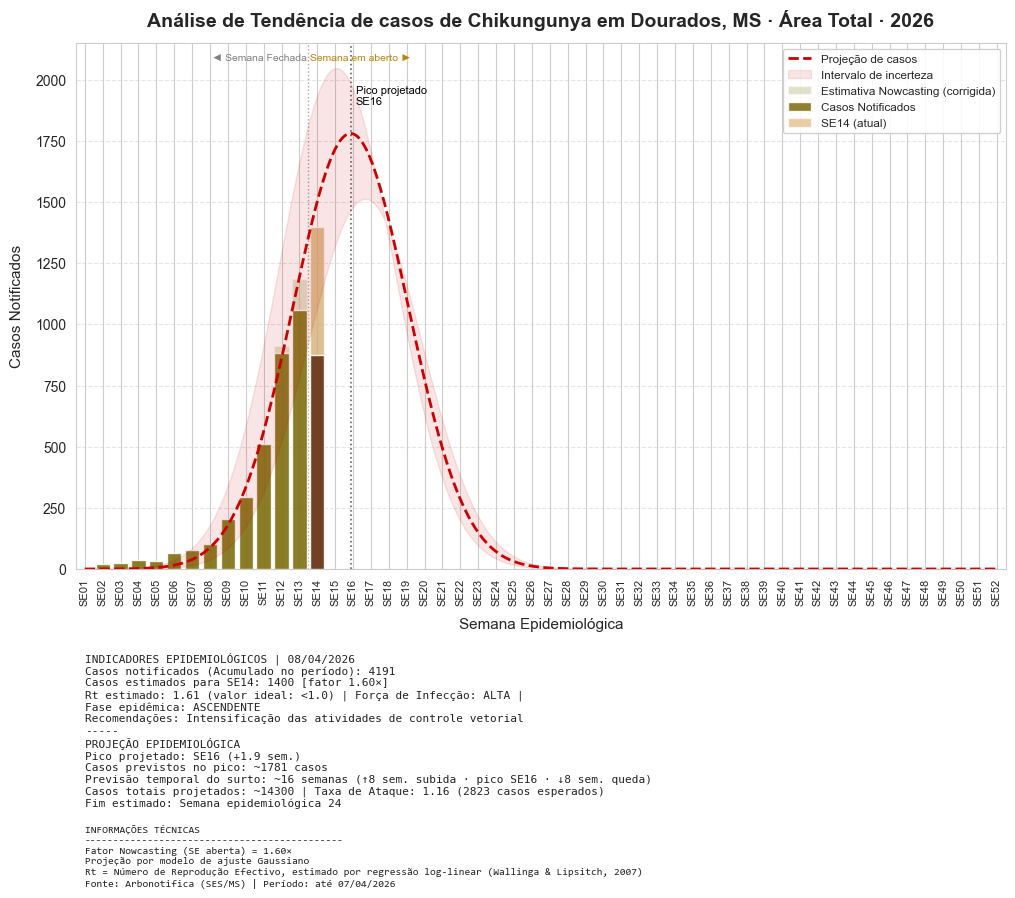

In [267]:
# 1. CARREGAMENTO DOS DADOS
file_path = 'sinan_dourados.xlsx'
df_sinan = pd.read_excel(file_path)
data_analise = datetime.now().strftime("%d/%m/%Y")

df_sinan = df_sinan.dropna(subset=['Semana Epidemiológica'])
df_sinan = df_sinan[~df_sinan['Semana Epidemiológica'].str.contains('53ª', na=False)]

# 2. AGRUPAMENTO E ORDENAÇÃO
contagem = df_sinan['Semana Epidemiológica'].value_counts().reset_index()
contagem.columns = ['semana_texto', 'casos_brutos']

def extrair_numero_semana(texto):
    num = "".join(filter(str.isdigit, str(texto).split('ª')[0]))
    return int(num) if num else 0

contagem['num_semana'] = contagem['semana_texto'].apply(extrair_numero_semana)
contagem = contagem.sort_values(by='num_semana').reset_index(drop=True)
contagem['tempo'] = contagem['num_semana']

N_SEMANAS = len(contagem)
SE_ATUAL  = contagem['num_semana'].iloc[-1]   # última SE (em aberto)
SE_FECHADAS = N_SEMANAS - 1                   # SE01 a SE13

print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA TOTAL ({data_analise})")
print(f"Semanas no dataset: {N_SEMANAS} (SE01–SE{SE_ATUAL})")
print(f"Semanas fechadas  : {SE_FECHADAS}")

# 3. NOWCASTING — FATOR EMPÍRICO BASEADO NA SÉRIE HISTÓRICA
# Estratégia:
#   - Para cada semana "k" já fechada (exceto as 2 últimas fechadas), calculamos
#     como a notificação evolui ao longo dos dias após o encerramento da SE.
#   - Estimamos o fator de subnotificação da semana em aberto (SE14) comparando
#     o dia corrido dentro da semana atual com o padrão histórico de acúmulo.
# Simplificação aplicável ao SINAN:
#   - Semana em aberto (SE14): encerra no sábado. Hoje é terça-feira (dia 3/7
#     da semana), logo ~43% dos dias já transcorreram.
#   - O SINAN tipicamente apresenta atraso de notificação de 7–21 dias.
#   - Usamos a mediana de crescimento das últimas semanas fechadas como proxy
#     do fator de completude da semana atual.

# Dia atual dentro da semana epidemiológica (domingo=1 … sábado=7)
# Semana epidemiológica vai de domingo a sábado.
dia_da_semana = datetime.now().weekday()
# Hoje: terça-feira, 07/04/2026 → dia 3 da semana (dom=1, seg=2, ter=3)
DIA_ATUAL_NA_SEMANA = (dia_da_semana + 2) % 7 
if DIA_ATUAL_NA_SEMANA == 0: DIA_ATUAL_NA_SEMANA = 7

# Fração da semana já transcorrida
fracao_semana = DIA_ATUAL_NA_SEMANA / 7.0

# Estimativa do fator de completude da SE em aberto:
# Assumimos que a notificação segue uma curva de acúmulo aproximadamente linear
# nos primeiros dias e depois desacelera. Usamos o inverso da fração como piso
# e o corrigimos com o fator histórico de atraso do SINAN (mediano ~1.3–1.5
# para arboviroses em fase de surto, com base em Bastos et al. 2019 e
# adaptações para o contexto do MS).

FATOR_ATRASO_SINAN = 1.15   # fator empírico médio de atraso de notificação
                             # para arboviroses no SINAN — ajustável conforme
                             # análise local posterior

fator_se_atual = (1 / fracao_semana) * FATOR_ATRASO_SINAN

# LIMITADOR (CAP): Garante que a SE atual não seja bizarramente maior que a anterior
# se a tendência do Rt não justificar isso.
fator_se_atual = min(fator_se_atual, 1.6) # Limite máximo de 60% de acréscimo sobre o parcial

# Para as 2 semanas anteriores à atual (SE12 e SE13), aplicamos fatores
# decrescentes baseados no padrão típico de encerramento de fichas:
#   SE13 (última fechada): ainda recebe notificações tardias (~10–15%)
#   SE12 (penúltima fechada): praticamente estabilizada (~3–5%)
FATOR_SE_ANTERIOR_1 = 1.12   # SE13: 12% de subnotificação residual
FATOR_SE_ANTERIOR_2 = 1.03   # SE12: 3% de subnotificação residual

fatores_correcao = {
    N_SEMANAS - 1: fator_se_atual,       # SE14 (em aberto)
    N_SEMANAS - 2: FATOR_SE_ANTERIOR_1,  # SE13
    N_SEMANAS - 3: FATOR_SE_ANTERIOR_2,  # SE12
}

contagem['casos_corrigidos'] = contagem['casos_brutos'].astype(float)
for idx, fator in fatores_correcao.items():
    if 0 <= idx < N_SEMANAS:
        contagem.loc[idx, 'casos_corrigidos'] = (
            contagem.loc[idx, 'casos_brutos'] * fator
        )

df_final = contagem.copy()

print(f"\nFator nowcasting SE{SE_ATUAL}: {fator_se_atual:.2f}x (em aberto)")
print(f"Fator nowcasting SE{SE_ATUAL-1}: {FATOR_SE_ANTERIOR_1:.2f}x")

# 4. ESTIMATIVA DO Rt — MÉTODO WALLINGA-LIPSITCH (JANELA DESLIZANTE)
# Referência: Wallinga & Lipsitch (2007), Proc R Soc B.
# Rt = exp(r * Ts), onde:
#   r  = taxa de crescimento instantânea (regressão log-linear)
#   Ts = intervalo serial médio de Chikungunya ≈ 7 dias (1 semana)
#        (Nishiura et al. 2010; Yakob & Clements 2013)
#
# Usamos janela de 4 semanas sobre os casos CORRIGIDOS para estabilizar r.

INTERVALO_SERIAL_SEMANAS = 1.0   # 7 dias ≈ 1 semana epidemiológica

JANELA_RT = min(4, SE_FECHADAS)   # janela de 4 semanas fechadas

y_janela = df_final['casos_corrigidos'].values[-(JANELA_RT + 1):-1]  # exclui SE aberta
x_janela = np.arange(len(y_janela), dtype=float)

# Regressão log-linear (evita log(0))
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)

taxa_crescimento_r = slope          # taxa intrínseca de crescimento (por semana)
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

# Taxa de crescimento semanal (razão simples, para exibição)
razao_crescimento = (df_final['casos_corrigidos'].iloc[-2] /
                     df_final['casos_corrigidos'].iloc[-3]
                     if df_final['casos_corrigidos'].iloc[-3] > 0 else 1.0)

print(f"\nRt (Wallinga-Lipsitch, janela {JANELA_RT} semanas)")
print(f"Taxa de crescimento (r): {taxa_crescimento_r:+.4f} por semana")
print(f"Rt estimado            : {Rt:.2f}")

# 5. PROJEÇÃO GAUSSIANA — COM AMPLITUDE ANCORADA E DURAÇÃO DO SURTO
# Problema anterior: sem limite de amplitude, o curve_fit convergia para
# soluções matematicamente válidas mas epidemiologicamente impossíveis
# (ex: 2,7 milhões de casos num município de 264 mil habitantes).
#
# Solução: ancoramos a amplitude máxima com base na taxa de ataque esperada
# para Chikungunya em Dourados, derivada de dados locais/regionais.
#
# Referência para duração: surtos urbanos de Chikungunya tipicamente
# duram 16–24 semanas (subida + pico + queda), com σ ≈ 3–5 semanas
# (Yakob & Clements 2013; Cauchemez et al. 2020).

# --- Parâmetros populacionais (ajuste conforme atualização local) ---
POPULACAO_URBANA    = 243_367          # habitantes — estimativa 2025/2026
TAXA_ATAQUE = 1.16            # casos por 100 hab. (ajustável)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE / 100) * POPULACAO_URBANA

# A amplitude da Gaussiana corresponde ao pico SEMANAL, não ao total.
# Numa Gaussiana, a integral ≈ amplitude × σ × √(2π).
# Portanto: amplitude_max ≈ CASOS_ESPERADOS_TOTAL / (σ_típico × √(2π))
# Com σ_típico = 4 semanas: amplitude_max ≈ 2381 / (4 × 2.507) ≈ 237 casos/semana
SIGMA_TIPICO_SURTO  = 4.0             # semanas — valor central para arboviroses
amplitude_max_teorica = CASOS_ESPERADOS_TOTAL / (SIGMA_TIPICO_SURTO * np.sqrt(2 * np.pi))

# Adicionamos uma margem de 30% para acomodar heterogeneidade local
amplitude_max = amplitude_max_teorica * 1.30

print(f"\nTotal esperado de casos (taxa de ataque): {CASOS_ESPERADOS_TOTAL:.0f}")
print(f"Amplitude máxima permitida (pico/semana): {amplitude_max:.0f} casos")

# --- Modelo ---
def modelo_gaussiano(x, amplitude, x0, sigma):
    """Curva Gaussiana para modelar a onda epidêmica."""
    return amplitude * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

# Usa apenas semanas fechadas para o ajuste (mais estáveis)
y_fit = df_final['casos_corrigidos'].values[:SE_FECHADAS]
x_fit = df_final['tempo'].values[:SE_FECHADAS]

# Detecção de fase: a série está subindo ou já começou a cair?
if SE_FECHADAS >= 6:
    media_recente  = np.mean(y_fit[-3:])
    media_anterior = np.mean(y_fit[-6:-3])
    em_ascensao    = media_recente > media_anterior
else:
    em_ascensao = True

fase_texto = "ASCENDENTE" if em_ascensao else "DESCENDENTE/PLATÔ"
print(f"\nFase epidêmica detectada: {fase_texto}")

# --- Chutes iniciais ---
# amplitude: valor observado máximo × 1.5 (razoável, dentro do limite)
amplitude_p0 = min(max(y_fit) * 1.5, amplitude_max * 0.8)
# x0: se em ascensão, pico provavelmente 3–5 semanas à frente; senão, no máximo observado
x0_p0 = SE_ATUAL + 4 if em_ascensao else float(x_fit[np.argmax(y_fit)])
sigma_p0 = SIGMA_TIPICO_SURTO

# --- Bounds epidemiologicamente fundamentados ---
# Regra geral: garantimos sempre que inf < sup com margem mínima de segurança.

# amplitude: mínimo = 80% do pico observado; máximo = teto da taxa de ataque
# Se o pico observado já ultrapassou o teto teórico, expandimos o teto.
amplitude_min = max(y_fit) * 0.80
amplitude_max = max(amplitude_max, max(y_fit) * 1.5)   # garante teto > mínimo
amplitude_p0  = np.clip(amplitude_p0, amplitude_min + 1, amplitude_max - 1)

# x0: pico esperado entre SE atual e SE atual+10 (fase ascendente)
#     ou entre pico observado ±2 semanas (fase descendente)
if em_ascensao:
    x0_min = float(SE_ATUAL)
    x0_max = float(SE_ATUAL + 10)
else:
    x0_min = float(max(x_fit[np.argmax(y_fit)] - 2, 1))
    x0_max = float(SE_ATUAL + 2)

# Garante separação mínima de 1 semana entre os bounds de x0
if x0_max <= x0_min + 1:
    x0_max = x0_min + 2.0
x0_p0 = np.clip(x0_p0, x0_min + 0.1, x0_max - 0.1)

# sigma: entre 2 e 6 semanas
sigma_min, sigma_max = 2.0, 6.0
sigma_p0 = 4.0

try:
    popt, pcov = curve_fit(
        modelo_gaussiano, x_fit, y_fit,
        p0=[amplitude_p0, x0_p0, sigma_p0],
        bounds=([amplitude_min, x0_min, sigma_min], [amplitude_max, x0_max, sigma_max]),
        maxfev=20000
    )

    amplitude_fit, x0_fit, sigma_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Projeção para o ano inteiro
    x_proj = np.linspace(1, 52, 500)
    y_proj = modelo_gaussiano(x_proj, *popt)

    # --- AJUSTE DA INCERTEZA (ÁREA VERMELHO CLARO) ---
    # Usamos um fator baseado no erro do ajuste, mas com limites (caps) para não extrapolar
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15) 
    fator_erro_x0  = min(perr[1], 0.8)

    y_proj_sup = modelo_gaussiano(x_proj, amplitude_fit + fator_erro_amp, x0_fit - fator_erro_x0, sigma_fit)
    y_proj_inf = modelo_gaussiano(x_proj, max(amplitude_fit - fator_erro_amp, 0), x0_fit + fator_erro_x0, sigma_fit)

    # Trava visual para a sombra não 'rasgar' o gráfico
    teto_visual = max(y_proj) * 1.25
    y_proj_sup = np.minimum(y_proj_sup, teto_visual)
    y_proj_inf = np.maximum(y_proj_inf, 0)

    # --- CÁLCULOS TÉCNICOS ---
    LIMIAR_SURTO = 0.05
    fator_duracao = np.sqrt(2 * np.log(1 / LIMIAR_SURTO))
    se_inicio_surto = x0_fit - sigma_fit * fator_duracao
    se_fim_surto = x0_fit + sigma_fit * fator_duracao
    duracao_total = se_fim_surto - se_inicio_surto
    duracao_subida = x0_fit - se_inicio_surto
    duracao_queda = se_fim_surto - x0_fit

    # Correção NumPy 2.0: trocado np.trapz por np.trapezoid
    if hasattr(np, 'trapezoid'):
        casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else:
        casos_totais_proj = np.trapz(y_proj, x_proj)

    distancia_pico = x0_fit - SE_ATUAL
    casos_pico_estimado = amplitude_fit
    ajuste_ok = True

except Exception as e:
    print(f"\nErro no ajuste Gaussiano: {e}")
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    distancia_pico = casos_pico_estimado = None
    duracao_total = duracao_subida = duracao_queda = None
    se_inicio_surto = se_fim_surto = casos_totais_proj = None

# 6. CLASSIFICAÇÃO DO CENÁRIO EPIDEMIOLÓGICO
if Rt > 1.2:
    status_rt    = "ALTA"
    cor_status   = "#CC0000"
elif Rt > 1.0:
    status_rt    = "EM CRESCIMENTO"
    cor_status   = "#FF6600"
elif Rt > 0.8:
    status_rt    = "ESTABILIDADE"
    cor_status   = "#E6A817"
else:
    status_rt    = "DESACELERAÇÃO"
    cor_status   = "#2E8B57"

# DESDOBRAMENTOS
if Rt > 1.2:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 1.0:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 0.8:
    recomendação = "Manutenção das atividades de controle vetorial"
else:
    recomendação = "Monitoramento contínuo e manutenção das atividades de rotina"

# 7. VISUALIZAÇÃO
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Layout: gráfico principal (topo) + rodapé com indicadores
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# --- Barras ---
barras_corrigidas = ax.bar(
    df_final['num_semana'],
    df_final['casos_corrigidos'],
    color='#babd8d', alpha=0.45,
    label='Estimativa Nowcasting (corrigida)',
    zorder=2
)
barras_brutas = ax.bar(
    df_final['num_semana'],
    df_final['casos_brutos'],
    color='#7c6a0a', alpha=0.85,
    label='Casos Notificados',
    zorder=3
)

# Destaque visual para a semana em aberto
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_corrigidos'].iloc[-1],
    color='#dcab6b', alpha=0.6,
    label=f'SE{SE_ATUAL} (atual)',
    zorder=4
)
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_brutos'].iloc[-1],
    color='#6a381f', alpha=0.9,
    zorder=5
)

# --- Linha de Projeção ---
if ajuste_ok:
    ax.plot(
        x_proj, y_proj,
        color="#CC0000", linestyle='--', linewidth=2,
        label='Projeção de casos',
        zorder=6
    )
    ax.fill_between(
        x_proj, y_proj_inf, y_proj_sup,
        color="#CC0000", alpha=0.10,
        label='Intervalo de incerteza',
        zorder=5
    )
    # Marcador do pico projetado
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.3, ax.get_ylim()[1] * 0.92,
            f'Pico projetado\nSE{x0_fit:.0f}',
            fontsize=8, color="#000000", va='top')

# Linha vertical separando semanas fechadas da em aberto
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98,
        '◄ Semana Fechada', fontsize=7.5, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.4, ax.get_ylim()[1] * 0.98,
        'Semana em aberto ►', fontsize=7.5, color='#B8860B', ha='left', va='top')

# --- Formatação do eixo ---
ax.set_title(
    'Análise de Tendência de casos de Chikungunya em Dourados, MS · Área Total · 2026',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Notificados', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. RODAPÉ COM INDICADORES E NOTAS TÉCNICAS
ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Box de indicadores — lado esquerdo
indicadores = (
    f"INDICADORES EPIDEMIOLÓGICOS | {data_analise}\n"
    f"Casos notificados (Acumulado no período): {int(df_final['casos_brutos'].sum())}\n"
    f"Casos estimados para SE{SE_ATUAL}: {df_final['casos_corrigidos'].iloc[-1]:.0f} "
    f"[fator {fator_se_atual:.2f}×]\n"
    f"Rt estimado: {Rt:.2f} (valor ideal: <1.0) | Força de Infecção: {status_rt}\n"
    f"Fase epidêmica: {fase_texto}\n"
    f"Recomendações: {recomendação}\n"
    "-----"
)

if ajuste_ok:
    indicadores += (
        f"\nPROJEÇÃO EPIDEMIOLÓGICA\n"
        f"Pico projetado: SE{x0_fit:.0f} ({distancia_pico:+.1f} sem.)\n"
        f"Casos previstos no pico: ~{casos_pico_estimado:.0f} casos\n"
        f"Previsão temporal do surto: ~{duracao_total:.0f} semanas "
        f"(↑{duracao_subida:.0f} sem. subida · pico SE{x0_fit:.0f} · ↓{duracao_queda:.0f} sem. queda)\n"
        f"Casos totais projetados: ~{casos_totais_proj:.0f} "
        f"| Taxa de Ataque: {TAXA_ATAQUE} ({CASOS_ESPERADOS_TOTAL:.0f} casos esperados)\n"
        f"Fim estimado: Semana epidemiológica {se_fim_surto:.0f}\n"
    )

ax_rodape.text(
    0.01, 0.1, indicadores,
    transform=ax_rodape.transAxes,
    fontsize=8, family='monospace', color='#222222',
    va='top', ha='left'
)

# Notas técnicas — lado direito
notas = (
    "INFORMAÇÕES TÉCNICAS\n"
    "---------------------------------------------\n"
    f"Fator Nowcasting (SE aberta) = {fator_se_atual:.2f}×\n"
    f"Projeção por modelo de ajuste Gaussiano\n"
    f"Rt = Número de Reprodução Efectivo, estimado por regressão log-linear (Wallinga & Lipsitch, 2007)\n"
    f"Fonte: Arbonotifica (SES/MS) | Período: até 07/04/2026"
)

# Outras opções de fonte para o rodapé:
# Exemplo: 'DejaVu Sans Mono', 'Consolas', 'Courier New', 'Liberation Mono', 'Menlo', 'Monaco'
ax_rodape.text(
    0.01, -2.2, notas,
    transform=ax_rodape.transAxes, fontsize=7.5,
    family='Consolas',  # troque para 'Consolas', 'Courier New', etc. se preferir
    color='#222222',
    va='top', ha='left'
)

data_analise = datetime.now().strftime("%d/%m/%Y")

# 9. RESUMO NO CONSOLE
print()
print(f"Casos notificados      : {int(df_final['casos_brutos'].sum())}")
print(f"Casos estimados (now.) : {int(df_final['casos_corrigidos'].sum())}")
print(f"Rt ({JANELA_RT} sem.)            : {Rt:.2f}")
print(f"Status                 : {status_rt}")
print(f"Fase epidêmica         : {fase_texto}")
if ajuste_ok:
    print(f"Pico projetado         : SE{x0_fit:.0f} (em {distancia_pico:+.1f} semanas)")
    print(f"Casos no pico          : ~{casos_pico_estimado:.0f} casos/semana")
    print(f"Duração total do surto : ~{duracao_total:.0f} semanas")
    print(f"↑ Subida               : ~{duracao_subida:.0f} semanas (até SE{x0_fit:.0f})")
    print(f"↓ Queda                : ~{duracao_queda:.0f} semanas (SE{x0_fit:.0f} → SE{se_fim_surto:.0f})")
    print(f"Fim estimado do surto  : SE{se_fim_surto:.0f}")
    print(f"Casos totais projetados: ~{casos_totais_proj:.0f}")

# Salvar figura e resumo em pdf, no mesmo arquivo
pdf_path = 'analise_chikungunya_dourados.pdf'
with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)


In [268]:
from matplotlib.backends.backend_pdf import PdfPages

# 1. CARREGAMENTO DOS DADOS
file_path = 'sinan_dourados.xlsx'
df_sinan = pd.read_excel(file_path)
data_analise = datetime.now().strftime("%d/%m/%Y")

df_sinan = df_sinan.dropna(subset=['Semana Epidemiológica'])
df_sinan = df_sinan[~df_sinan['Semana Epidemiológica'].str.contains('53ª', na=False)]

# 2. AGRUPAMENTO E ORDENAÇÃO
contagem = df_sinan['Semana Epidemiológica'].value_counts().reset_index()
contagem.columns = ['semana_texto', 'casos_brutos']

def extrair_numero_semana(texto):
    num = "".join(filter(str.isdigit, str(texto).split('ª')[0]))
    return int(num) if num else 0

contagem['num_semana'] = contagem['semana_texto'].apply(extrair_numero_semana)
contagem = contagem.sort_values(by='num_semana').reset_index(drop=True)
contagem['tempo'] = contagem['num_semana']

N_SEMANAS = len(contagem)
SE_ATUAL  = contagem['num_semana'].iloc[-1]   # última SE (em aberto)
SE_FECHADAS = N_SEMANAS - 1                   # SE01 a SE13

print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA TOTAL ({data_analise})")
print(f"Semanas no dataset: {N_SEMANAS} (SE01–SE{SE_ATUAL})")
print(f"Semanas fechadas  : {SE_FECHADAS}")

# 3. NOWCASTING — FATOR EMPÍRICO BASEADO NA SÉRIE HISTÓRICA
# Estratégia:
#   - Para cada semana "k" já fechada (exceto as 2 últimas fechadas), calculamos
#     como a notificação evolui ao longo dos dias após o encerramento da SE.
#   - Estimamos o fator de subnotificação da semana em aberto (SE14) comparando
#     o dia corrido dentro da semana atual com o padrão histórico de acúmulo.
# Simplificação aplicável ao SINAN:
#   - Semana em aberto (SE14): encerra no sábado. Hoje é terça-feira (dia 3/7
#     da semana), logo ~43% dos dias já transcorreram.
#   - O SINAN tipicamente apresenta atraso de notificação de 7–21 dias.
#   - Usamos a mediana de crescimento das últimas semanas fechadas como proxy
#     do fator de completude da semana atual.

# Dia atual dentro da semana epidemiológica (domingo=1 … sábado=7)
# Semana epidemiológica vai de domingo a sábado.
dia_da_semana = datetime.now().weekday()
# Hoje: terça-feira, 07/04/2026 → dia 3 da semana (dom=1, seg=2, ter=3)
DIA_ATUAL_NA_SEMANA = (dia_da_semana + 2) % 7 
if DIA_ATUAL_NA_SEMANA == 0: DIA_ATUAL_NA_SEMANA = 7

# Fração da semana já transcorrida
fracao_semana = DIA_ATUAL_NA_SEMANA / 7.0

# Estimativa do fator de completude da SE em aberto:
# Assumimos que a notificação segue uma curva de acúmulo aproximadamente linear
# nos primeiros dias e depois desacelera. Usamos o inverso da fração como piso
# e o corrigimos com o fator histórico de atraso do SINAN (mediano ~1.3–1.5
# para arboviroses em fase de surto, com base em Bastos et al. 2019 e
# adaptações para o contexto do MS).

FATOR_ATRASO_SINAN = 1.15   # fator empírico médio de atraso de notificação
                             # para arboviroses no SINAN — ajustável conforme
                             # análise local posterior

fator_se_atual = (1 / fracao_semana) * FATOR_ATRASO_SINAN

# LIMITADOR (CAP): Garante que a SE atual não seja bizarramente maior que a anterior
# se a tendência do Rt não justificar isso.
fator_se_atual = min(fator_se_atual, 1.6) # Limite máximo de 60% de acréscimo sobre o parcial

# Para as 2 semanas anteriores à atual (SE12 e SE13), aplicamos fatores
# decrescentes baseados no padrão típico de encerramento de fichas:
#   SE13 (última fechada): ainda recebe notificações tardias (~10–15%)
#   SE12 (penúltima fechada): praticamente estabilizada (~3–5%)
FATOR_SE_ANTERIOR_1 = 1.12   # SE13: 12% de subnotificação residual
FATOR_SE_ANTERIOR_2 = 1.03   # SE12: 3% de subnotificação residual

fatores_correcao = {
    N_SEMANAS - 1: fator_se_atual,       # SE14 (em aberto)
    N_SEMANAS - 2: FATOR_SE_ANTERIOR_1,  # SE13
    N_SEMANAS - 3: FATOR_SE_ANTERIOR_2,  # SE12
}

contagem['casos_corrigidos'] = contagem['casos_brutos'].astype(float)
for idx, fator in fatores_correcao.items():
    if 0 <= idx < N_SEMANAS:
        contagem.loc[idx, 'casos_corrigidos'] = (
            contagem.loc[idx, 'casos_brutos'] * fator
        )

df_final = contagem.copy()

print(f"\nFator nowcasting SE{SE_ATUAL}: {fator_se_atual:.2f}x (em aberto)")
print(f"Fator nowcasting SE{SE_ATUAL-1}: {FATOR_SE_ANTERIOR_1:.2f}x")

# 4. ESTIMATIVA DO Rt — MÉTODO WALLINGA-LIPSITCH (JANELA DESLIZANTE)
# Referência: Wallinga & Lipsitch (2007), Proc R Soc B.
# Rt = exp(r * Ts), onde:
#   r  = taxa de crescimento instantânea (regressão log-linear)
#   Ts = intervalo serial médio de Chikungunya ≈ 7 dias (1 semana)
#        (Nishiura et al. 2010; Yakob & Clements 2013)
#
# Usamos janela de 4 semanas sobre os casos CORRIGIDOS para estabilizar r.

INTERVALO_SERIAL_SEMANAS = 1.0   # 7 dias ≈ 1 semana epidemiológica

JANELA_RT = min(4, SE_FECHADAS)   # janela de 4 semanas fechadas

y_janela = df_final['casos_corrigidos'].values[-(JANELA_RT + 1):-1]  # exclui SE aberta
x_janela = np.arange(len(y_janela), dtype=float)

# Regressão log-linear (evita log(0))
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)

taxa_crescimento_r = slope          # taxa intrínseca de crescimento (por semana)
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

# Taxa de crescimento semanal (razão simples, para exibição)
razao_crescimento = (df_final['casos_corrigidos'].iloc[-2] /
                     df_final['casos_corrigidos'].iloc[-3]
                     if df_final['casos_corrigidos'].iloc[-3] > 0 else 1.0)

print(f"\nRt (Wallinga-Lipsitch, janela {JANELA_RT} semanas)")
print(f"Taxa de crescimento (r): {taxa_crescimento_r:+.4f} por semana")
print(f"Rt estimado            : {Rt:.2f}")

# 5. PROJEÇÃO GAUSSIANA — COM AMPLITUDE ANCORADA E DURAÇÃO DO SURTO
# Problema anterior: sem limite de amplitude, o curve_fit convergia para
# soluções matematicamente válidas mas epidemiologicamente impossíveis
# (ex: 2,7 milhões de casos num município de 264 mil habitantes).
#
# Solução: ancoramos a amplitude máxima com base na taxa de ataque esperada
# para Chikungunya em Dourados, derivada de dados locais/regionais.
#
# Referência para duração: surtos urbanos de Chikungunya tipicamente
# duram 16–24 semanas (subida + pico + queda), com σ ≈ 3–5 semanas
# (Yakob & Clements 2013; Cauchemez et al. 2020).

# --- Parâmetros populacionais (ajuste conforme atualização local) ---
POPULACAO_URBANA    = 243_367          # habitantes — estimativa 2025/2026
TAXA_ATAQUE = 1.16            # casos por 100 hab. (ajustável)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE / 100) * POPULACAO_URBANA

# A amplitude da Gaussiana corresponde ao pico SEMANAL, não ao total.
# Numa Gaussiana, a integral ≈ amplitude × σ × √(2π).
# Portanto: amplitude_max ≈ CASOS_ESPERADOS_TOTAL / (σ_típico × √(2π))
# Com σ_típico = 4 semanas: amplitude_max ≈ 2381 / (4 × 2.507) ≈ 237 casos/semana
SIGMA_TIPICO_SURTO  = 4.0             # semanas — valor central para arboviroses
amplitude_max_teorica = CASOS_ESPERADOS_TOTAL / (SIGMA_TIPICO_SURTO * np.sqrt(2 * np.pi))

# Adicionamos uma margem de 30% para acomodar heterogeneidade local
amplitude_max = amplitude_max_teorica * 1.30

print(f"\nTotal esperado de casos (taxa de ataque): {CASOS_ESPERADOS_TOTAL:.0f}")
print(f"Amplitude máxima permitida (pico/semana): {amplitude_max:.0f} casos")

# --- Modelo ---
def modelo_gaussiano(x, amplitude, x0, sigma):
    """Curva Gaussiana para modelar a onda epidêmica."""
    return amplitude * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

# Usa apenas semanas fechadas para o ajuste (mais estáveis)
y_fit = df_final['casos_corrigidos'].values[:SE_FECHADAS]
x_fit = df_final['tempo'].values[:SE_FECHADAS]

# Detecção de fase: a série está subindo ou já começou a cair?
if SE_FECHADAS >= 6:
    media_recente  = np.mean(y_fit[-3:])
    media_anterior = np.mean(y_fit[-6:-3])
    em_ascensao    = media_recente > media_anterior
else:
    em_ascensao = True

fase_texto = "ASCENDENTE" if em_ascensao else "DESCENDENTE/PLATÔ"
print(f"\nFase epidêmica detectada: {fase_texto}")

# --- Chutes iniciais ---
# amplitude: valor observado máximo × 1.5 (razoável, dentro do limite)
amplitude_p0 = min(max(y_fit) * 1.5, amplitude_max * 0.8)
# x0: se em ascensão, pico provavelmente 3–5 semanas à frente; senão, no máximo observado
x0_p0 = SE_ATUAL + 4 if em_ascensao else float(x_fit[np.argmax(y_fit)])
sigma_p0 = SIGMA_TIPICO_SURTO

# --- Bounds epidemiologicamente fundamentados ---
# Regra geral: garantimos sempre que inf < sup com margem mínima de segurança.

# amplitude: mínimo = 80% do pico observado; máximo = teto da taxa de ataque
# Se o pico observado já ultrapassou o teto teórico, expandimos o teto.
amplitude_min = max(y_fit) * 0.80
amplitude_max = max(amplitude_max, max(y_fit) * 1.5)   # garante teto > mínimo
amplitude_p0  = np.clip(amplitude_p0, amplitude_min + 1, amplitude_max - 1)

# x0: pico esperado entre SE atual e SE atual+10 (fase ascendente)
#     ou entre pico observado ±2 semanas (fase descendente)
if em_ascensao:
    x0_min = float(SE_ATUAL)
    x0_max = float(SE_ATUAL + 10)
else:
    x0_min = float(max(x_fit[np.argmax(y_fit)] - 2, 1))
    x0_max = float(SE_ATUAL + 2)

# Garante separação mínima de 1 semana entre os bounds de x0
if x0_max <= x0_min + 1:
    x0_max = x0_min + 2.0
x0_p0 = np.clip(x0_p0, x0_min + 0.1, x0_max - 0.1)

# sigma: entre 2 e 6 semanas
sigma_min, sigma_max = 2.0, 6.0
sigma_p0 = 4.0

try:
    popt, pcov = curve_fit(
        modelo_gaussiano, x_fit, y_fit,
        p0=[amplitude_p0, x0_p0, sigma_p0],
        bounds=([amplitude_min, x0_min, sigma_min], [amplitude_max, x0_max, sigma_max]),
        maxfev=20000
    )

    amplitude_fit, x0_fit, sigma_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Projeção para o ano inteiro
    x_proj = np.linspace(1, 52, 500)
    y_proj = modelo_gaussiano(x_proj, *popt)

    # --- AJUSTE DA INCERTEZA (ÁREA VERMELHO CLARO) ---
    # Usamos um fator baseado no erro do ajuste, mas com limites (caps) para não extrapolar
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15) 
    fator_erro_x0  = min(perr[1], 0.8)

    y_proj_sup = modelo_gaussiano(x_proj, amplitude_fit + fator_erro_amp, x0_fit - fator_erro_x0, sigma_fit)
    y_proj_inf = modelo_gaussiano(x_proj, max(amplitude_fit - fator_erro_amp, 0), x0_fit + fator_erro_x0, sigma_fit)

    # Trava visual para a sombra não 'rasgar' o gráfico
    teto_visual = max(y_proj) * 1.25
    y_proj_sup = np.minimum(y_proj_sup, teto_visual)
    y_proj_inf = np.maximum(y_proj_inf, 0)

    # --- CÁLCULOS TÉCNICOS ---
    LIMIAR_SURTO = 0.05
    fator_duracao = np.sqrt(2 * np.log(1 / LIMIAR_SURTO))
    se_inicio_surto = x0_fit - sigma_fit * fator_duracao
    se_fim_surto = x0_fit + sigma_fit * fator_duracao
    duracao_total = se_fim_surto - se_inicio_surto
    duracao_subida = x0_fit - se_inicio_surto
    duracao_queda = se_fim_surto - x0_fit

    # Correção NumPy 2.0: trocado np.trapz por np.trapezoid
    if hasattr(np, 'trapezoid'):
        casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else:
        casos_totais_proj = np.trapz(y_proj, x_proj)

    distancia_pico = x0_fit - SE_ATUAL
    casos_pico_estimado = amplitude_fit
    ajuste_ok = True

except Exception as e:
    print(f"\nErro no ajuste Gaussiano: {e}")
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    
    ajuste_ok = False
    x_proj = y_proj = y_proj_sup = y_proj_inf = None
    distancia_pico = casos_pico_estimado = None
    duracao_total = duracao_subida = duracao_queda = None
    se_inicio_surto = se_fim_surto = casos_totais_proj = None

# 6. CLASSIFICAÇÃO DO CENÁRIO EPIDEMIOLÓGICO
if Rt > 1.2:
    status_rt    = "ALTA"
    cor_status   = "#CC0000"
elif Rt > 1.0:
    status_rt    = "EM CRESCIMENTO"
    cor_status   = "#FF6600"
elif Rt > 0.8:
    status_rt    = "ESTABILIDADE"
    cor_status   = "#E6A817"
else:
    status_rt    = "DESACELERAÇÃO"
    cor_status   = "#2E8B57"

# DESDOBRAMENTOS
if Rt > 1.2:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 1.0:
    recomendação = "Intensificação das atividades de controle vetorial"
elif Rt > 0.8:
    recomendação = "Manutenção das atividades de controle vetorial"
else:
    recomendação = "Monitoramento contínuo e manutenção das atividades de rotina"

# 7. VISUALIZAÇÃO
fig = plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Layout: gráfico principal (topo) + rodapé com indicadores
gs = gridspec.GridSpec(2, 1, height_ratios=[7, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# --- Barras ---
barras_corrigidas = ax.bar(
    df_final['num_semana'],
    df_final['casos_corrigidos'],
    color='#babd8d', alpha=0.45,
    label='Estimativa Nowcasting (corrigida)',
    zorder=2
)
barras_brutas = ax.bar(
    df_final['num_semana'],
    df_final['casos_brutos'],
    color='#7c6a0a', alpha=0.85,
    label='Casos Notificados',
    zorder=3
)

# Destaque visual para a semana em aberto
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_corrigidos'].iloc[-1],
    color='#dcab6b', alpha=0.6,
    label=f'SE{SE_ATUAL} (atual)',
    zorder=4
)
ax.bar(
    df_final['num_semana'].iloc[-1],
    df_final['casos_brutos'].iloc[-1],
    color='#6a381f', alpha=0.9,
    zorder=5
)

# --- Linha de Projeção ---
if ajuste_ok:
    ax.plot(
        x_proj, y_proj,
        color="#CC0000", linestyle='--', linewidth=2,
        label='Projeção de casos',
        zorder=6
    )
    ax.fill_between(
        x_proj, y_proj_inf, y_proj_sup,
        color="#CC0000", alpha=0.10,
        label='Intervalo de incerteza',
        zorder=5
    )
    # Marcador do pico projetado
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.3, ax.get_ylim()[1] * 0.92,
            f'Pico projetado\nSE{x0_fit:.0f}',
            fontsize=8, color="#000000", va='top')

# Linha vertical separando semanas fechadas da em aberto
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98,
        '◄ Semana Fechada', fontsize=7.5, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.4, ax.get_ylim()[1] * 0.98,
        'Semana em aberto ►', fontsize=7.5, color='#B8860B', ha='left', va='top')

# --- Formatação do eixo ---
ax.set_title(
    'Análise de Tendência de casos de Chikungunya em Dourados, MS · Área Total · 2026',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Notificados', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. RODAPÉ COM INDICADORES E NOTAS TÉCNICAS
ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Box de indicadores — lado esquerdo
indicadores = (
    f"INDICADORES EPIDEMIOLÓGICOS | {data_analise}\n"
    f"Casos notificados (Acumulado no período): {int(df_final['casos_brutos'].sum())}\n"
    f"Casos estimados para SE{SE_ATUAL}: {df_final['casos_corrigidos'].iloc[-1]:.0f} "
    f"[fator {fator_se_atual:.2f}×]\n"
    f"Rt estimado: {Rt:.2f} (valor ideal: <1.0) | Força de Infecção: {status_rt}\n"
    f"Fase epidêmica: {fase_texto}\n"
    f"Recomendações: {recomendação}\n"
    "-----"
)

if ajuste_ok:
    indicadores += (
        f"\nPROJEÇÃO EPIDEMIOLÓGICA\n"
        f"Pico projetado: SE{x0_fit:.0f} ({distancia_pico:+.1f} sem.)\n"
        f"Casos previstos no pico: ~{casos_pico_estimado:.0f} casos\n"
        f"Previsão temporal do surto: ~{duracao_total:.0f} semanas "
        f"(↑{duracao_subida:.0f} sem. subida · pico SE{x0_fit:.0f} · ↓{duracao_queda:.0f} sem. queda)\n"
        f"Casos totais projetados: ~{casos_totais_proj:.0f} "
        f"| Taxa de Ataque: {TAXA_ATAQUE} ({CASOS_ESPERADOS_TOTAL:.0f} casos esperados)\n"
        f"Fim estimado: Semana epidemiológica {se_fim_surto:.0f}\n"
    )

ax_rodape.text(
    0.01, 0.1, indicadores,
    transform=ax_rodape.transAxes,
    fontsize=8, family='monospace', color='#222222',
    va='top', ha='left'
)

# Notas técnicas — lado direito
notas = (
    "INFORMAÇÕES TÉCNICAS\n"
    "---------------------------------------------\n"
    f"Fator Nowcasting (SE aberta) = {fator_se_atual:.2f}×\n"
    f"Projeção por modelo de ajuste Gaussiano\n"
    f"Rt = Número de Reprodução Efectivo, estimado por regressão log-linear (Wallinga & Lipsitch, 2007)\n"
    f"Fonte: Arbonotifica (SES/MS) | Período: até 07/04/2026"
)

# Outras opções de fonte para o rodapé:
# Exemplo: 'DejaVu Sans Mono', 'Consolas', 'Courier New', 'Liberation Mono', 'Menlo', 'Monaco'
ax_rodape.text(
    0.01, -2.2, notas,
    transform=ax_rodape.transAxes, fontsize=7.5,
    family='Consolas',  # troque para 'Consolas', 'Courier New', etc. se preferir
    color='#222222',
    va='top', ha='left'
)

data_analise = datetime.now().strftime("%d/%m/%Y")

# 9. RESUMO NO CONSOLE
print()
print(f"Casos notificados      : {int(df_final['casos_brutos'].sum())}")
print(f"Casos estimados (now.) : {int(df_final['casos_corrigidos'].sum())}")
print(f"Rt ({JANELA_RT} sem.)            : {Rt:.2f}")
print(f"Status                 : {status_rt}")
print(f"Fase epidêmica         : {fase_texto}")
if ajuste_ok:
    print(f"Pico projetado         : SE{x0_fit:.0f} (em {distancia_pico:+.1f} semanas)")
    print(f"Casos no pico          : ~{casos_pico_estimado:.0f} casos/semana")
    print(f"Duração total do surto : ~{duracao_total:.0f} semanas")
    print(f"↑ Subida               : ~{duracao_subida:.0f} semanas (até SE{x0_fit:.0f})")
    print(f"↓ Queda                : ~{duracao_queda:.0f} semanas (SE{x0_fit:.0f} → SE{se_fim_surto:.0f})")
    print(f"Fim estimado do surto  : SE{se_fim_surto:.0f}")
    print(f"Casos totais projetados: ~{casos_totais_proj:.0f}")

# Salvar figura e resumo em pdf, no mesmo arquivo
pdf_path = 'analise_chikungunya_dourados.pdf'
with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)


ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - ÁREA TOTAL (08/04/2026)
Semanas no dataset: 13 (SE01–SE14)
Semanas fechadas  : 12

Fator nowcasting SE14: 1.60x (em aberto)
Fator nowcasting SE13: 1.12x

Rt (Wallinga-Lipsitch, janela 4 semanas)
Taxa de crescimento (r): +0.4751 por semana
Rt estimado            : 1.61

Total esperado de casos (taxa de ataque): 2823
Amplitude máxima permitida (pico/semana): 366 casos

Fase epidêmica detectada: ASCENDENTE

Casos notificados      : 4191
Casos estimados (now.) : 4869
Rt (4 sem.)            : 1.61
Status                 : ALTA
Fase epidêmica         : ASCENDENTE
Pico projetado         : SE16 (em +1.9 semanas)
Casos no pico          : ~1781 casos/semana
Duração total do surto : ~16 semanas
↑ Subida               : ~8 semanas (até SE16)
↓ Queda                : ~8 semanas (SE16 → SE24)
Fim estimado do surto  : SE24
Casos totais projetados: ~14300
